In [2]:
import os

print(os.listdir())

['.config', 'Titanic-Dataset.csv', 'sample_data']


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

/tmp/ipykernel_1075/1350759943.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_1075/1350759943.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

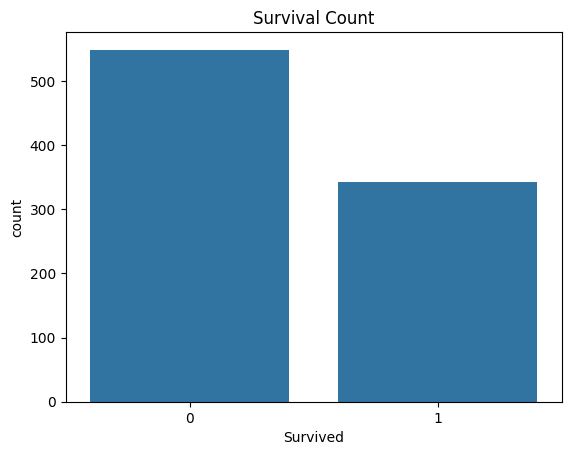

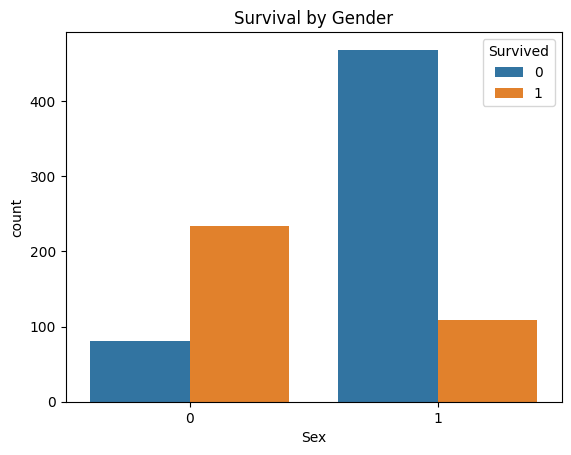

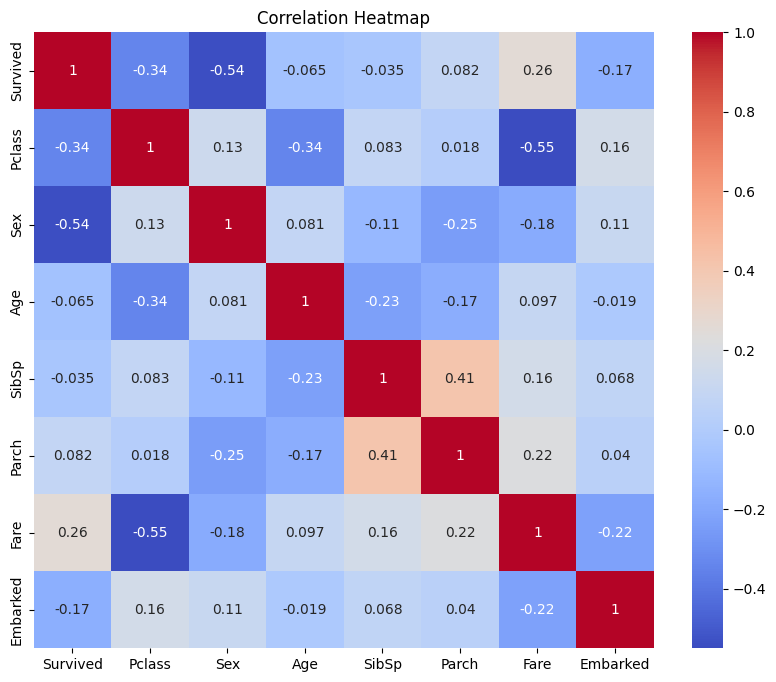

Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



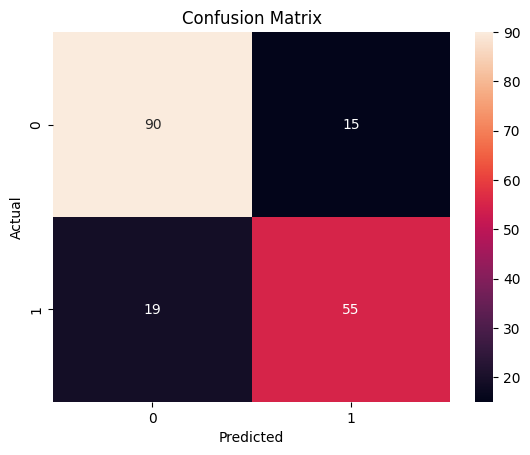

Passenger Did Not Survive
PROJECT COMPLETED SUCCESSFULLY


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [3]:
# ==========================================
# TITANIC SURVIVAL PREDICTION PROJECT
# ==========================================

# STEP 1 — IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# STEP 2 — LOAD DATASET

df = pd.read_csv('Titanic-Dataset.csv')

print(df.head())


# STEP 3 — CHECK DATASET

print(df.shape)

print(df.info())

print(df.isnull().sum())


# STEP 4 — HANDLE MISSING VALUES

df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop('Cabin', axis=1, inplace=True)


# STEP 5 — ENCODE CATEGORICAL DATA

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])


# STEP 6 — DROP UNNECESSARY COLUMNS

df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)


# STEP 7 — VISUALIZATION

sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# STEP 8 — FEATURES AND TARGET

X = df.drop('Survived', axis=1)

y = df['Survived']


# STEP 9 — TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# STEP 10 — TRAIN MODEL

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


# STEP 11 — PREDICTIONS

y_pred = model.predict(X_test)


# STEP 12 — ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


# STEP 13 — CLASSIFICATION REPORT

print(classification_report(y_test, y_pred))


# STEP 14 — CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()


# STEP 15 — CUSTOM PREDICTION

sample = [[3, 1, 22, 1, 0, 7.25, 2]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")


print("PROJECT COMPLETED SUCCESSFULLY")